<a href="https://colab.research.google.com/github/192512041simats-hari/IOE-AND-AI-SYSTEM/blob/main/IOE%20EXP_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

===== Energy Load Prediction Model Performance =====
Mean Absolute Error (MAE)   : 4.857 kW
Mean Squared Error (MSE)    : 23.714 kW^2
Root Mean Squared Error     : 4.870 kW
Mean Absolute % Error(MAPE) : 1.856 %
R-squared (R2 Score)        : 0.9860

Hour-wise Errors (Actual - Predicted):
Hour 1: -5 kW
Hour 2: 5 kW
Hour 3: -5 kW
Hour 4: 4 kW
Hour 5: -5 kW
Hour 6: 5 kW
Hour 7: -5 kW


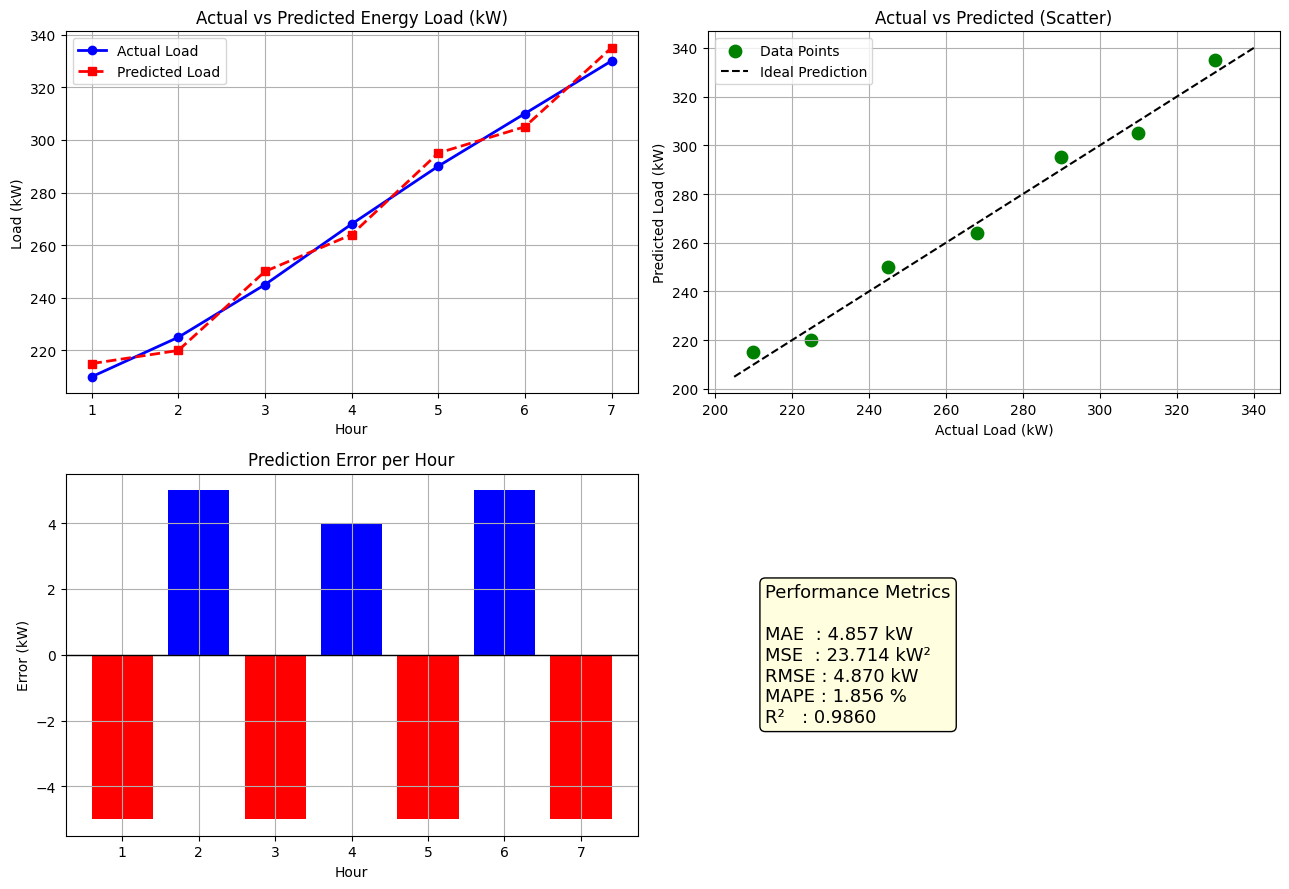

In [1]:

# AI-Based Smart Grid Energy Load Prediction Model Evaluation
# --------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Step 1: Input Data
hours = np.array([1, 2, 3, 4, 5, 6, 7])
actual = np.array([210, 225, 245, 268, 290, 310, 330])
predicted = np.array([215, 220, 250, 264, 295, 305, 335])

# Step 2: Performance Metrics
mae = mean_absolute_error(actual, predicted)
mse = mean_squared_error(actual, predicted)
rmse = np.sqrt(mse)
mape = np.mean(np.abs((actual - predicted) / actual)) * 100
r2 = r2_score(actual, predicted)

print("===== Energy Load Prediction Model Performance =====")
print(f"Mean Absolute Error (MAE)   : {mae:.3f} kW")
print(f"Mean Squared Error (MSE)    : {mse:.3f} kW^2")
print(f"Root Mean Squared Error     : {rmse:.3f} kW")
print(f"Mean Absolute % Error(MAPE) : {mape:.3f} %")
print(f"R-squared (R2 Score)        : {r2:.4f}")

# Step 3: Error values per hour
errors = actual - predicted
print("\nHour-wise Errors (Actual - Predicted):")
for h, e in zip(hours, errors):
    print(f"Hour {h}: {e} kW")

# Step 4: Visualization
fig, axs = plt.subplots(2, 2, figsize=(13, 9))

# (a) Line plot: Actual vs Predicted
axs[0, 0].plot(hours, actual, marker='o', label='Actual Load', color='blue', linewidth=2)
axs[0, 0].plot(hours, predicted, marker='s', label='Predicted Load', color='red', linewidth=2, linestyle='--')
axs[0, 0].set_title('Actual vs Predicted Energy Load (kW)')
axs[0, 0].set_xlabel('Hour')
axs[0, 0].set_ylabel('Load (kW)')
axs[0, 0].legend()
axs[0, 0].grid(True)

# (b) Scatter plot: Actual vs Predicted with ideal line
axs[0, 1].scatter(actual, predicted, color='green', s=80, label='Data Points')
lims = [min(actual.min(), predicted.min()) - 5, max(actual.max(), predicted.max()) + 5]
axs[0, 1].plot(lims, lims, color='black', linestyle='--', label='Ideal Prediction')
axs[0, 1].set_title('Actual vs Predicted (Scatter)')
axs[0, 1].set_xlabel('Actual Load (kW)')
axs[0, 1].set_ylabel('Predicted Load (kW)')
axs[0, 1].legend()
axs[0, 1].grid(True)

# (c) Bar plot: Hour-wise Error
axs[1, 0].bar(hours, errors, color=['red' if e < 0 else 'blue' for e in errors])
axs[1, 0].axhline(0, color='black', linewidth=1)
axs[1, 0].set_title('Prediction Error per Hour')
axs[1, 0].set_xlabel('Hour')
axs[1, 0].set_ylabel('Error (kW)')
axs[1, 0].grid(True)

# (d) Metrics summary as text
axs[1, 1].axis('off')
metrics_text = (
    f"Performance Metrics\n\n"
    f"MAE  : {mae:.3f} kW\n"
    f"MSE  : {mse:.3f} kW²\n"
    f"RMSE : {rmse:.3f} kW\n"
    f"MAPE : {mape:.3f} %\n"
    f"R²   : {r2:.4f}"
)
axs[1, 1].text(0.1, 0.5, metrics_text, fontsize=13, va='center',
               bbox=dict(boxstyle="round", facecolor="lightyellow"))

plt.tight_layout()
plt.show()